In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# Load Dataset
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


**Observation:**
The Wine dataset contains different chemical properties of wines. Since all variables are numerical, it is suitable for clustering and dimensionality reduction.

In [3]:
# Check Missing Values
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


**Observation:**
There are no missing values in the dataset.

In [4]:
# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

**Observation**
Standardization scales all features to have mean 0 and standard deviation 1, preventing variables with larger values from dominating the clustering process.

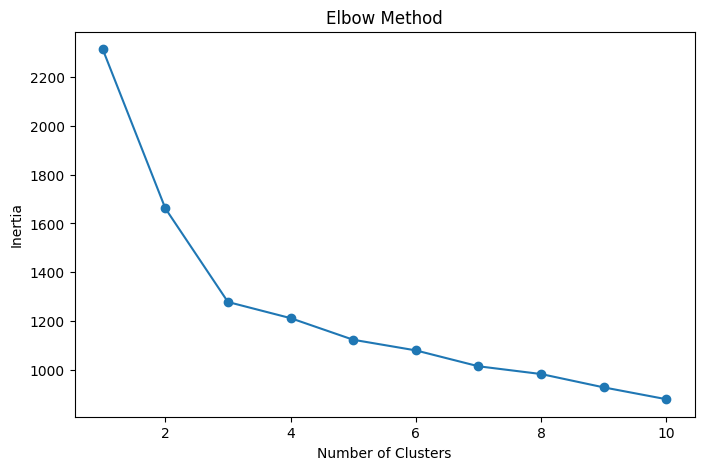

In [5]:
# Elbow Method
inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The Elbow Method was used to determine the optimal number of clusters for the K-Means algorithm. The graph shows a sharp decrease in inertia from K = 1 to K = 3, indicating significant improvement in cluster formation. After K = 3, the curve begins to flatten, meaning additional clusters provide only a small reduction in inertia. Therefore, 3 was selected as the optimal number of clusters for the clustering analysis.

In [6]:
# K-Means Clustering

kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_data)

df['KMeans Cluster'] = kmeans_labels

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,KMeans Cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,2
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,2
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,2
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,2
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,2


Obsevation: In the output all samples belong to Cluster 2, indicating that they have similar chemical characteristics and were grouped together by the algorithm. The clustering process helps identify natural patterns in the dataset without using predefined class labels.

In [7]:
# Silhouette Score
score = silhouette_score(scaled_data, kmeans_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.2848589191898987


**Observation:** The Silhouette Score of 0.28 indicates that the clusters are reasonably separated but have some overlap. Since the score is greater than 0, the clustering algorithm has identified meaningful groups in the dataset. Although the clustering quality is moderate rather than excellent, it is acceptable for the Wine dataset. This suggests that K-Means was able to group similar wine samples effectively based on their features.

In [8]:
# PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])

pca_df['Cluster'] = kmeans_labels

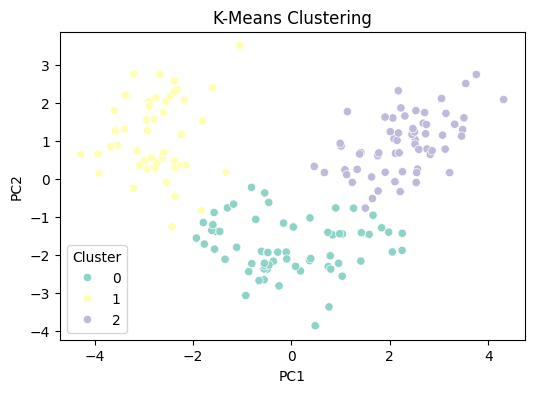

In [10]:
# Plot K-Means Clusters

plt.figure(figsize=(6,4))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set3'
)

plt.title("K-Means Clustering")
plt.show()

**Obsevation:** The scatter plot shows the K-Means clustering results after reducing the dataset to two principal components (PC1 and PC2) using PCA. The data points are grouped into three distinct clusters (0, 1, and 2), represented by different colors. Most clusters are well separated, indicating that the K-Means algorithm successfully identified groups of wine samples with similar characteristics. This visualization confirms that K = 3 is an appropriate choice for clustering the Wine dataset.

In [11]:
# Hierarchical Clustering

hierarchical = AgglomerativeClustering(n_clusters=3)

h_labels = hierarchical.fit_predict(scaled_data)

df['Hierarchical Cluster'] = h_labels

In [12]:
# Evaluate Hierarchical Model

score2 = silhouette_score(scaled_data, h_labels)

print("Hierarchical Silhouette Score:", score2)

Hierarchical Silhouette Score: 0.2774439826952266


**Observation: **The Hierarchical Clustering model achieved a Silhouette Score of 0.2774, which is close to 0.28 obtained by the K-Means model. This indicates that the clusters are reasonably well separated, although there is some overlap between them. The positive silhouette score shows that the model has successfully grouped similar wine samples together. Overall, the Hierarchical Clustering model provides satisfactory clustering performance on the Wine dataset.

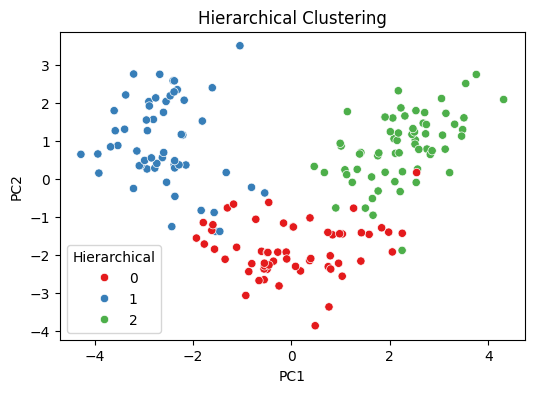

In [13]:
# Visualize Hierarchical Clusters

pca_df['Hierarchical'] = h_labels

plt.figure(figsize=(6,4))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Hierarchical',
    data=pca_df,
    palette='Set1'
)

plt.title("Hierarchical Clustering")
plt.show()

**Explaination:** The scatter plot shows the Hierarchical Clustering results after reducing the dataset to two principal components (PC1 and PC2) using PCA. The wine samples are grouped into three distinct clusters (0, 1, and 2), represented by different colors. Most of the clusters are clearly separated, indicating that the hierarchical clustering algorithm successfully identified natural groupings within the dataset. This visualization demonstrates that the model effectively clustered wine samples based on their similar chemical characteristics.

In [14]:
# Compare Models

print("K-Means Silhouette Score:", score)

print("Hierarchical Silhouette Score:", score2)

K-Means Silhouette Score: 0.2848589191898987
Hierarchical Silhouette Score: 0.2774439826952266


**Explaination:** The silhouette scores of the two clustering models were compared to evaluate their performance. K-Means achieved a silhouette score of 0.2849, while Hierarchical Clustering achieved 0.2774. Since the K-Means score is slightly higher, it indicates that its clusters are better separated and more compact. Therefore, K-Means is selected as the better-performing clustering algorithm for the Wine dataset, although both models produced satisfactory clustering results.

**Deployment Strategy:**
Some challenges that may occur include:

The model may take longer to process if a large amount of wine data

1.   List item
2.   List item

is added.
It may become difficult to handle an increasing number of wine samples over time.
New wine samples may have different characteristics, which can reduce the accuracy of the clusters.
The model should be checked and updated regularly to maintain good performance.

**Monitoring Strategy:**
The deployed model should be monitored by:

Checking the silhouette score regularly to make sure the clustering performance remains good.
Watching for changes in the wine data that could affect the clustering results.
Retraining the model from time to time using new wine samples.
Keeping a record of the clustering results to ensure the model is working correctly.
Reviewing the number of clusters and updating it if new data changes the grouping pattern.

**Conclusion:**
The Wine dataset was analyzed using unsupervised learning techniques. Both K-Means and Hierarchical Clustering were used to group similar wine samples, and PCA was used to reduce the data into two dimensions for easier visualization. Based on the silhouette scores, K-Means performed slightly better than Hierarchical Clustering. Finally, simple deployment and monitoring strategies were suggested to help keep the model accurate and reliable when used with new data.

Git hub Link: https://github.com/7500nidhi/Assignment9_c12.git